In [1]:
import pandas as pd
import numpy as np
from math import sqrt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [2]:
# Using backward selection for feature selection

def backward_eliminate(df_features, target, estimator):
    active_feats = list(df_features.columns)
    history = []
    rmse_trace = []
    r2_trace = []
    removed_feats = []

    while len(active_feats) > 1:
        X_train, X_valid, y_train, y_valid = train_test_split(
            df_features[active_feats], target, test_size=0.2, random_state=42
        )
        estimator.fit(X_train, y_train)
        preds = estimator.predict(X_valid)
        rmse_val = sqrt(mean_squared_error(y_valid, preds))
        r2_val = r2_score(y_valid, preds)
        history.append((active_feats.copy(), rmse_val, r2_val))
        rmse_trace.append(rmse_val)
        r2_trace.append(r2_val)
        importances = estimator.feature_importances_
        lowest_feat = active_feats[np.argmin(importances)]
        active_feats.remove(lowest_feat)
        removed_feats.append(lowest_feat)

    return history, rmse_trace, r2_trace, removed_feats



In [3]:
# Function: plot RMSE and R² trends

def draw_performance_curve(rmse_vals, r2_vals, dropped, title):
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(rmse_vals, 'o-', label='Validation RMSE')
    ax1.set_xlabel('Removed Features')
    ax1.set_ylabel('RMSE')
    ax1.set_xticks(range(len(dropped)))
    ax1.set_xticklabels(dropped, rotation=45)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(r2_vals, 's--', color='orange', label='Validation R²')
    ax2.set_ylabel('R²')
    ax2.legend(loc='upper right')
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [4]:
# Function: render density maps using hexbin 

def render_density_map(true_rf, true_fso, pred_rf, pred_fso, subtitle):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Measured attenuation
    hb1 = axes[0].hexbin(true_rf, true_fso, gridsize=25, mincnt=1, cmap='viridis')
    axes[0].set_xlabel('RF Att. (dB)')
    axes[0].set_ylabel('FSO Att. (dB)')
    axes[0].set_title(f'{subtitle} – Measured Attenuation')
    plt.colorbar(hb1, ax=axes[0], label='Count')
    
    # Predicted attenuation
    hb2 = axes[1].hexbin(pred_rf, pred_fso, gridsize=25, mincnt=1, cmap='plasma')
    axes[1].set_xlabel('RF Att. (dB)')
    axes[1].set_ylabel('FSO Att. (dB)')
    axes[1].set_title(f'{subtitle} – Predicted Attenuation')
    plt.colorbar(hb2, ax=axes[1], label='Count')

    plt.tight_layout()
    plt.show()



Processing: Clear (code 0)


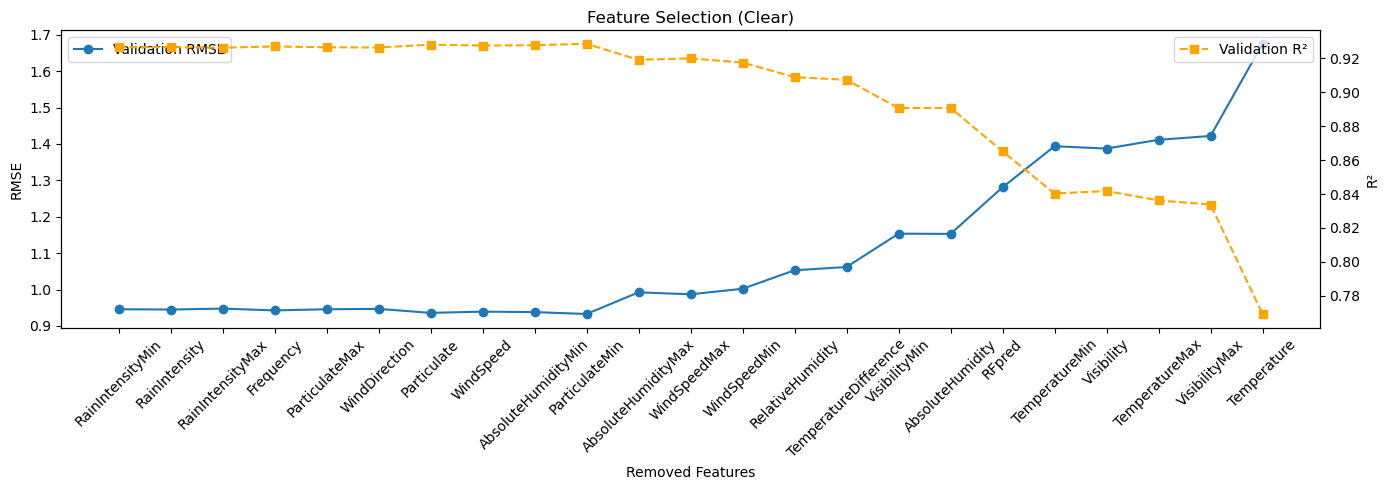

Chosen features for FSO: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'Distance', 'ParticulateMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindSpeedMax', 'WindSpeedMin', 'RFpred']
Optimal hyperparameters for FSO model (Clear): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


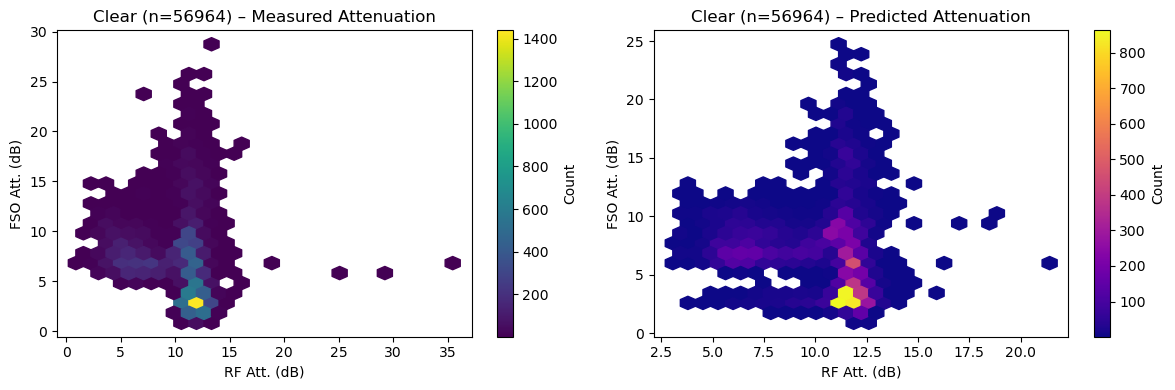


Processing: Dust (code 3)


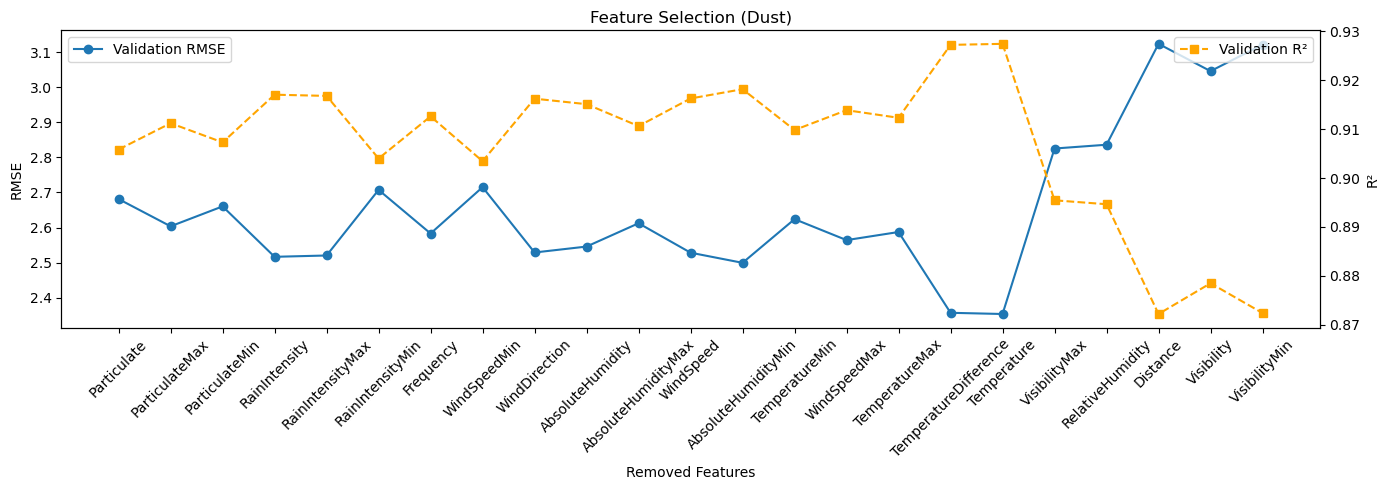

Chosen features for FSO: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeed', 'WindSpeedMax', 'WindSpeedMin', 'RFpred']
Optimal hyperparameters for FSO model (Dust): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


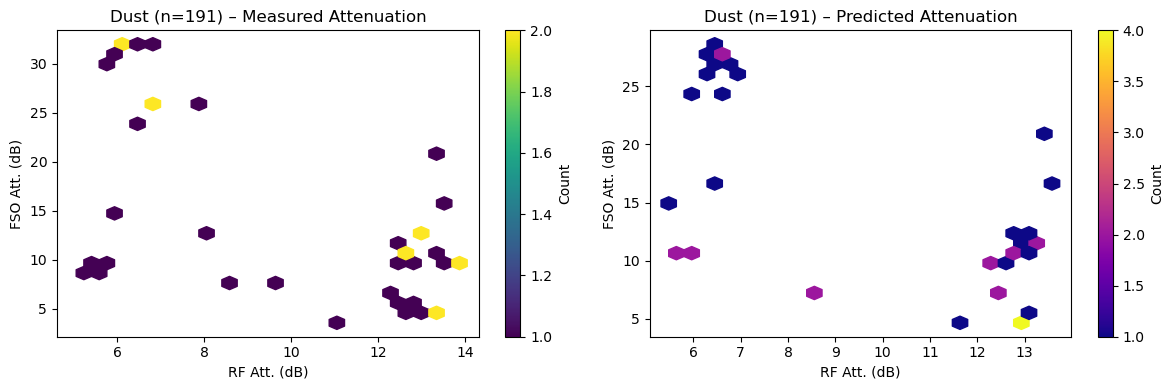


Processing: Fog (code 4)


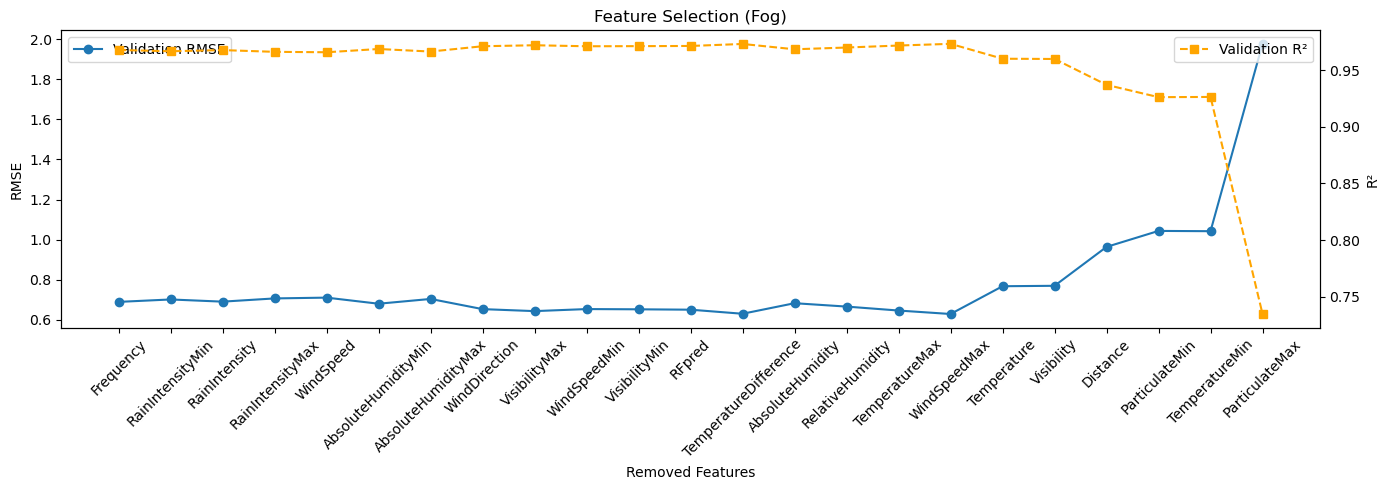

Chosen features for FSO: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeed', 'WindSpeedMax', 'WindSpeedMin', 'RFpred']
Optimal hyperparameters for FSO model (Fog): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


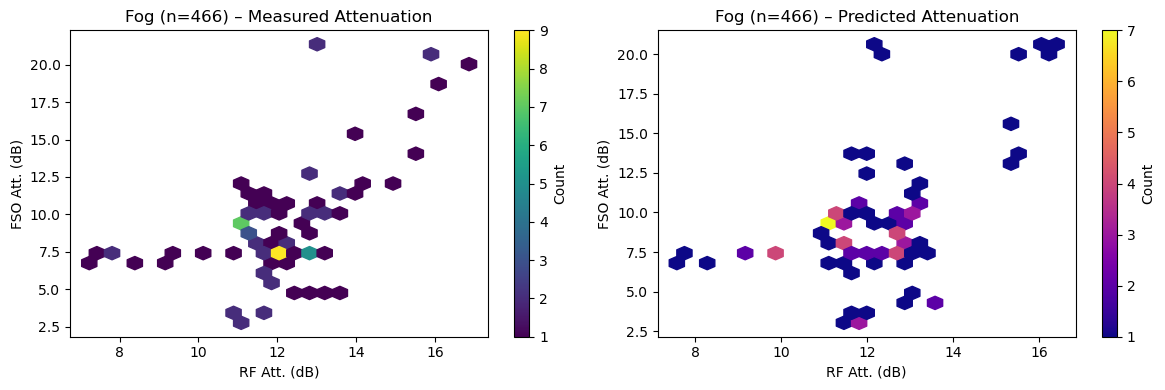


Processing: Drizzle (code 5)


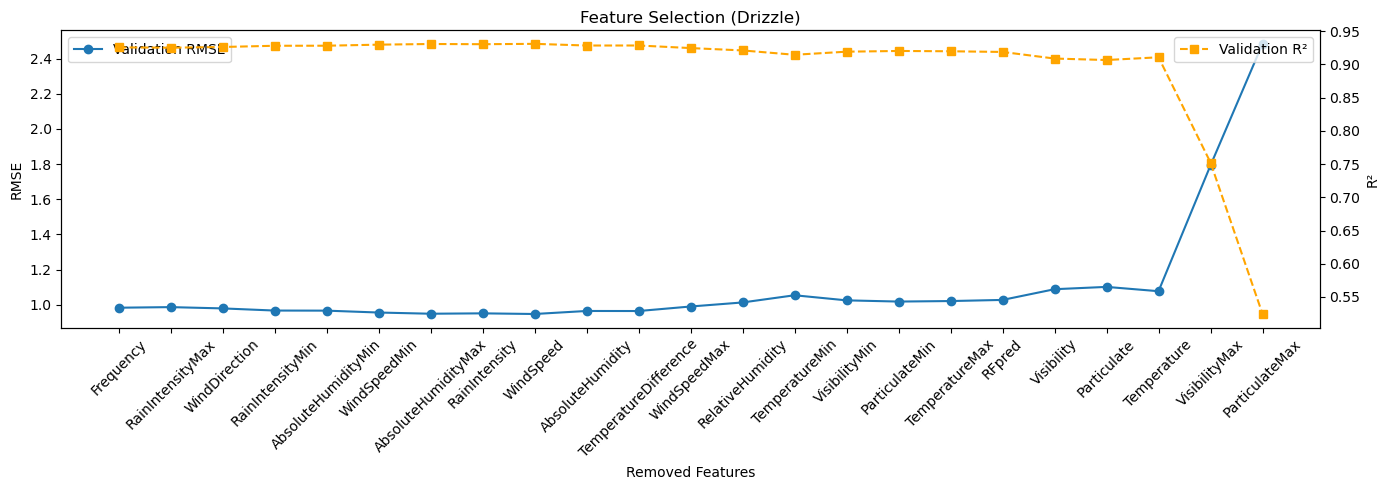

Chosen features for FSO: ['AbsoluteHumidity', 'Distance', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindSpeed', 'WindSpeedMax', 'RFpred']
Optimal hyperparameters for FSO model (Drizzle): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


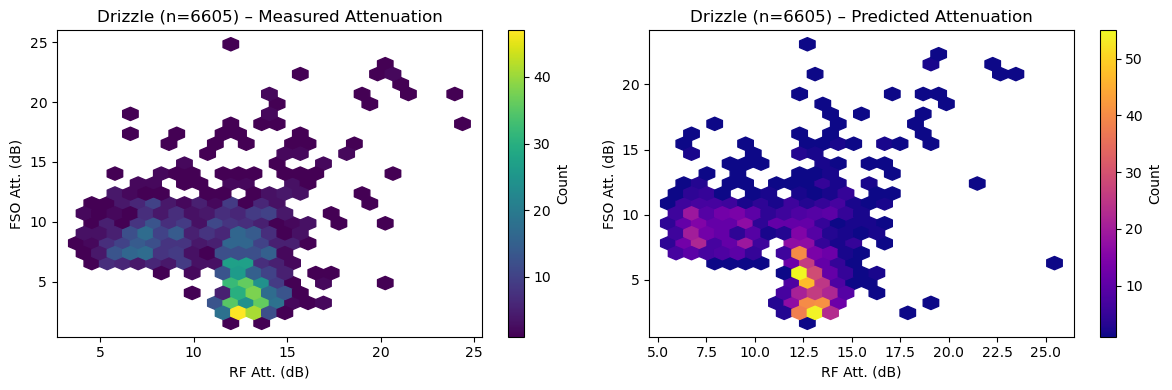


Processing: Rain (code 6)


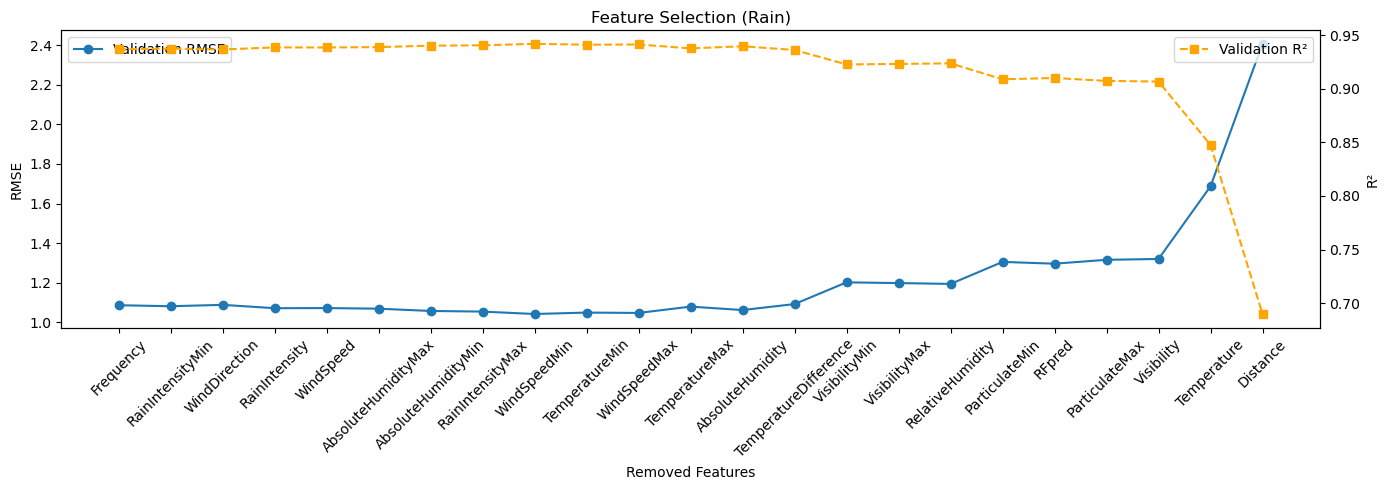

Chosen features for FSO: ['AbsoluteHumidity', 'Distance', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindSpeedMax', 'RFpred']
Optimal hyperparameters for FSO model (Rain): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


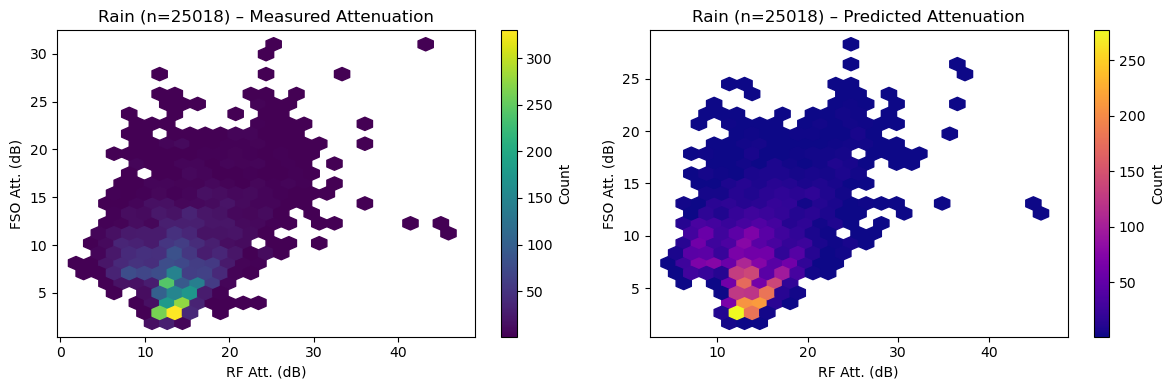


Processing: Snow (code 7)


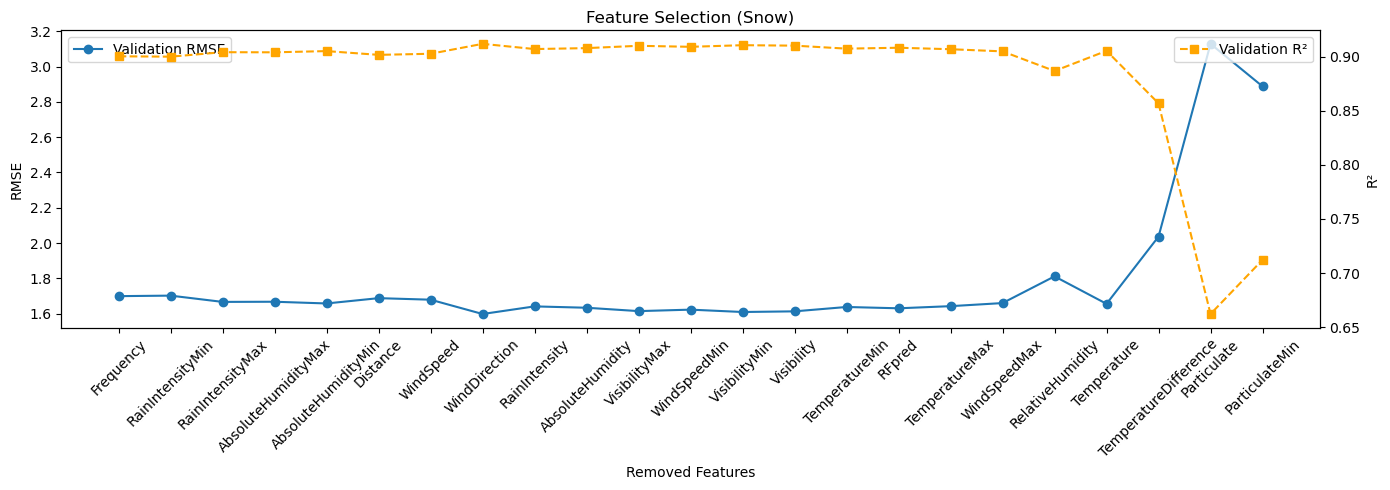

Chosen features for FSO: ['AbsoluteHumidity', 'AbsoluteHumidityMin', 'Distance', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeed', 'WindSpeedMax', 'WindSpeedMin', 'RFpred']
Optimal hyperparameters for FSO model (Snow): {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


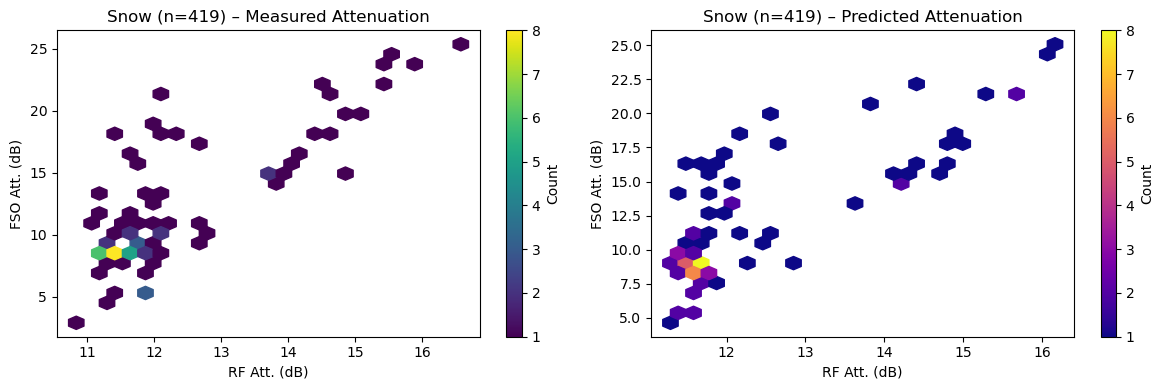


Processing: Showers (code 8)


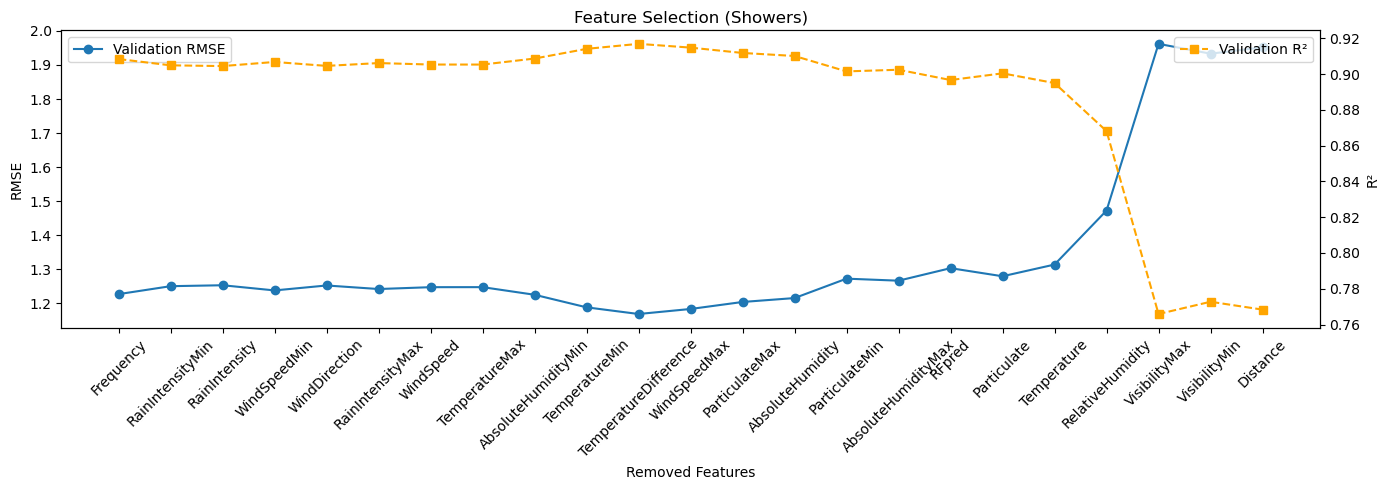

Chosen features for FSO: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeed', 'WindSpeedMax', 'WindSpeedMin', 'RFpred']
Optimal hyperparameters for FSO model (Showers): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


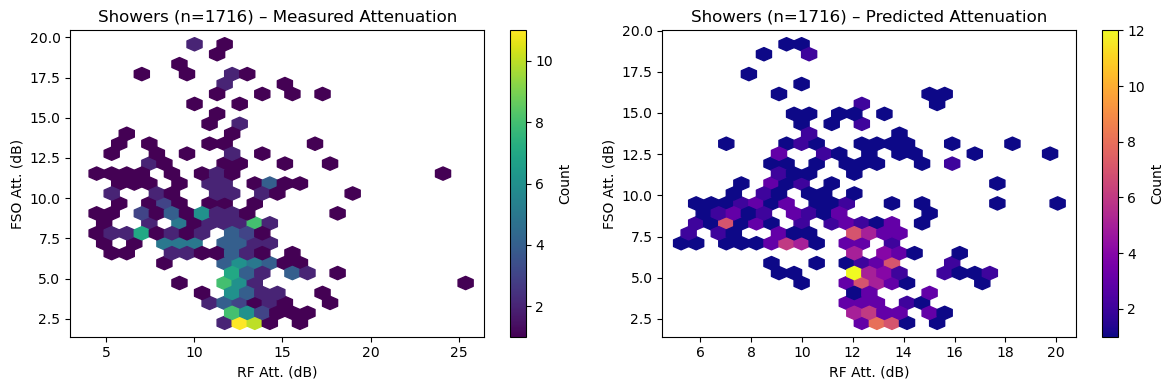


=== Summary Results ===
   Weather   RF_RMSE     RF_R2  FSO_RMSE    FSO_R2  Corr_Actual  \
0    Clear  1.360123  0.718226  0.931011  0.931719    -0.267705   
1     Dust  0.586189  0.968148  1.835624  0.961348    -0.424294   
2      Fog  0.642426  0.854993  0.770209  0.961609     0.577887   
3  Drizzle  0.982527  0.887864  1.006213  0.920870    -0.155631   
4     Rain  1.113942  0.921370  0.956944  0.949843     0.348307   
5     Snow  0.366387  0.927456  0.960947  0.965492     0.804480   
6  Showers  1.414336  0.766453  1.018988  0.929564    -0.169827   

   Corr_Predicted                                         FSO_Params  
0       -0.201031  {'n_estimators': 50, 'min_samples_split': 2, '...  
1       -0.619594  {'n_estimators': 100, 'min_samples_split': 2, ...  
2        0.500429  {'n_estimators': 50, 'min_samples_split': 2, '...  
3       -0.197925  {'n_estimators': 100, 'min_samples_split': 2, ...  
4        0.330395  {'n_estimators': 100, 'min_samples_split': 2, ...  
5        0.7

In [5]:
if __name__ == '__main__':
    # Load data
    data = pd.read_csv('RFLFSODataFull.csv')

    # Weather codes mapping
    code_map = {
        'Clear': 0, 'Dust': 3, 'Fog': 4,
        'Drizzle': 5, 'Rain': 6, 'Snow': 7, 'Showers': 8
    }

    # Predefined RF input sets per weather code
    rf_inputs = {
        0: ['AbsoluteHumidityMin', 'Visibility', 'Temperature', 'AbsoluteHumidityMax', 'AbsoluteHumidity'],
        3: ['TemperatureDifference', 'AbsoluteHumidityMin', 'TemperatureMax', 'TemperatureMin', 'AbsoluteHumidityMax', 'Temperature'],
        4: ['RainIntensityMin', 'RainIntensity', 'AbsoluteHumidityMin'],
        5: ['Distance', 'RainIntensityMax', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin'],
        6: ['Visibility', 'RainIntensityMin', 'Temperature', 'RainIntensityMax', 'AbsoluteHumidity'],
        7: ['AbsoluteHumidity', 'RainIntensityMax', 'RainIntensity', 'WindSpeedMax', 'RainIntensityMin'],
        8: ['RainIntensity', 'Particulate', 'AbsoluteHumidityMax', 'RainIntensityMin']
    }

    summary = []

    for weather, wcode in code_map.items():
        df_sub = data[data['SYNOPCode'] == wcode]
        if df_sub.shape[0] < 10:
            print(f"{weather}: too few rows ({df_sub.shape[0]}) - skipped")
            continue
        print(f"\nProcessing: {weather} (code {wcode})")

        X = df_sub.drop(['RFL_Att','FSO_Att'], axis=1)
        y_rf = df_sub['RFL_Att']
        y_fso = df_sub['FSO_Att']

        X_tr, X_te, y_rf_tr, y_rf_te, y_fso_tr, y_fso_te = train_test_split(
            X, y_rf, y_fso, test_size=0.2, random_state=42
        )

        # RF baseline
        rf_feats = rf_inputs[wcode]
        rf_mod = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_mod.fit(X_tr[rf_feats], y_rf_tr)
        rf_tr_pred = rf_mod.predict(X_tr[rf_feats])
        rf_te_pred = rf_mod.predict(X_te[rf_feats])

        # FSO feature elimination
        fso_data_tr = X_tr.drop(['Time','SYNOPCode'], axis=1).copy()
        fso_data_tr['RFpred'] = rf_tr_pred
        hist, rmses, r2s, drops = backward_eliminate(
            fso_data_tr, y_fso_tr,
            RandomForestRegressor(n_estimators=50, random_state=42)
        )
        draw_performance_curve(rmses, r2s, drops, f"Feature Selection ({weather})")

        # choose best features
        diffs = np.diff(rmses)
        idx = np.where(diffs > 0.01)[0]
        best_ix = idx[0] if idx.size else int(np.argmin(rmses))
        best_feats = hist[best_ix][0]
        print(f"Chosen features for FSO: {best_feats}")

        # Hyperparameter search
        grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        search = RandomizedSearchCV(
            RandomForestRegressor(random_state=42),
            param_distributions=grid, n_iter=20, cv=5,
            scoring='neg_mean_squared_error', n_jobs=-1, random_state=42
        )
        search.fit(fso_data_tr[best_feats], y_fso_tr)

        # Print out the optimal hyperparameters
        print(f"Optimal hyperparameters for FSO model ({weather}): {search.best_params_}")

        best_params = search.best_params_
        fso_mod = RandomForestRegressor(**best_params, random_state=42)
        fso_mod.fit(fso_data_tr[best_feats], y_fso_tr)

        # Evaluate
        fso_data_te = X_te.drop(['Time','SYNOPCode'], axis=1).copy()
        fso_data_te['RFpred'] = rf_te_pred
        fso_te_pred = fso_mod.predict(fso_data_te[best_feats])

        m_rmse = sqrt(mean_squared_error(y_rf_te, rf_te_pred))
        m_r2   = r2_score(y_rf_te, rf_te_pred)
        f_rmse = sqrt(mean_squared_error(y_fso_te, fso_te_pred))
        f_r2   = r2_score(y_fso_te, fso_te_pred)
        corr_meas, _ = pearsonr(df_sub['RFL_Att'], df_sub['FSO_Att'])
        corr_pred, _ = pearsonr(rf_te_pred, fso_te_pred)

        summary.append({
            'Weather': weather,
            'RF_RMSE': m_rmse, 'RF_R2': m_r2,
            'FSO_RMSE': f_rmse, 'FSO_R2': f_r2,
            'Corr_Actual': corr_meas, 'Corr_Predicted': corr_pred,
            'FSO_Params': search.best_params_
        })

        # Plot per-weather density maps
        render_density_map(
            true_rf=y_rf_te.values,
            true_fso=y_fso_te.values,
            pred_rf=rf_te_pred,
            pred_fso=fso_te_pred,
            subtitle=f"{weather} (n={len(df_sub)})"
        )

    # Summary table
    summary_df = pd.DataFrame(summary)
    print("\n=== Summary Results ===")
    print(summary_df)

    

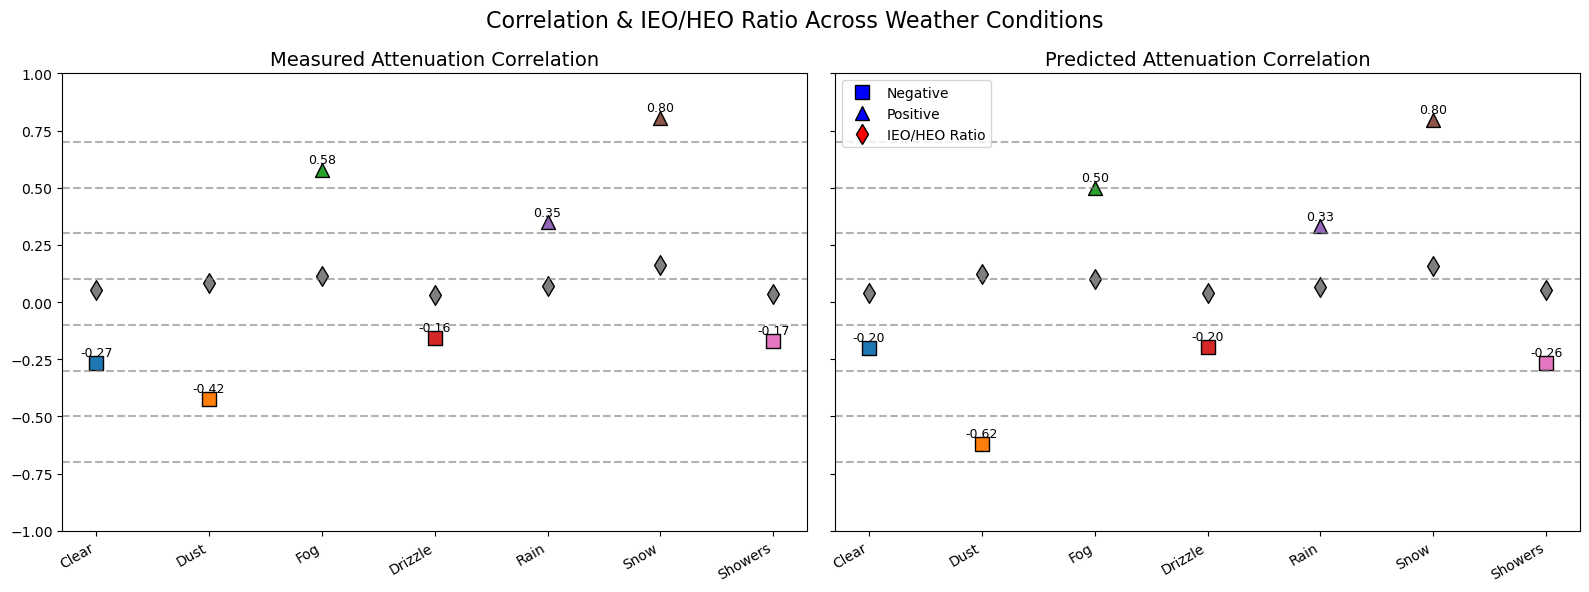

In [6]:
# Final correlation comparison plot

measured_ieo_heo  = np.abs(summary_df['Corr_Actual'].values) * 0.2
predicted_ieo_heo = np.abs(summary_df['Corr_Predicted'].values) * 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left plot: measured correlations
for i, corr in enumerate(summary_df['Corr_Actual']):
    mark = '^' if corr >= 0 else 's'
    ax1.scatter(i, corr, marker=mark, s=100, edgecolors='black')
    ax1.text(i, corr + 0.03, f"{corr:.2f}", ha='center', fontsize=9)
ax1.scatter(range(len(summary_df)), measured_ieo_heo, marker='d', s=100, edgecolors='black')
ax1.set_title("Measured Attenuation Correlation", fontsize=14)
ax1.set_xticks(range(len(summary_df)))
ax1.set_xticklabels(summary_df['Weather'], rotation=30, ha='right')
ax1.set_ylim(-1, 1)

for y in [0.7, 0.5, 0.3, 0.1, -0.1, -0.3, -0.5, -0.7]:
    ax1.axhline(y, color='gray', linestyle='--', alpha=0.6)

# Right plot: predicted correlations
for i, corr in enumerate(summary_df['Corr_Predicted']):
    mark = '^' if corr >= 0 else 's'
    ax2.scatter(i, corr, marker=mark, s=100, edgecolors='black')
    ax2.text(i, corr + 0.03, f"{corr:.2f}", ha='center', fontsize=9)
ax2.scatter(range(len(summary_df)), predicted_ieo_heo, marker='d', s=100, edgecolors='black')
ax2.set_title("Predicted Attenuation Correlation", fontsize=14)
ax2.set_xticks(range(len(summary_df)))
ax2.set_xticklabels(summary_df['Weather'], rotation=30, ha='right')
ax2.set_ylim(-1, 1)
for y in [0.7, 0.5, 0.3, 0.1, -0.1, -0.3, -0.5, -0.7]:
    ax2.axhline(y, color='gray', linestyle='--', alpha=0.6)

handles = [
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', label='Negative', markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='Positive', markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='d', color='w', markerfacecolor='red', label='IEO/HEO Ratio', markersize=10, markeredgecolor='black')
    ]

ax2.legend(handles=handles, loc='upper left', fontsize=10)

plt.suptitle("Correlation & IEO/HEO Ratio Across Weather Conditions", fontsize=16)
plt.tight_layout()
plt.show()


Processing: Clear (code 0)


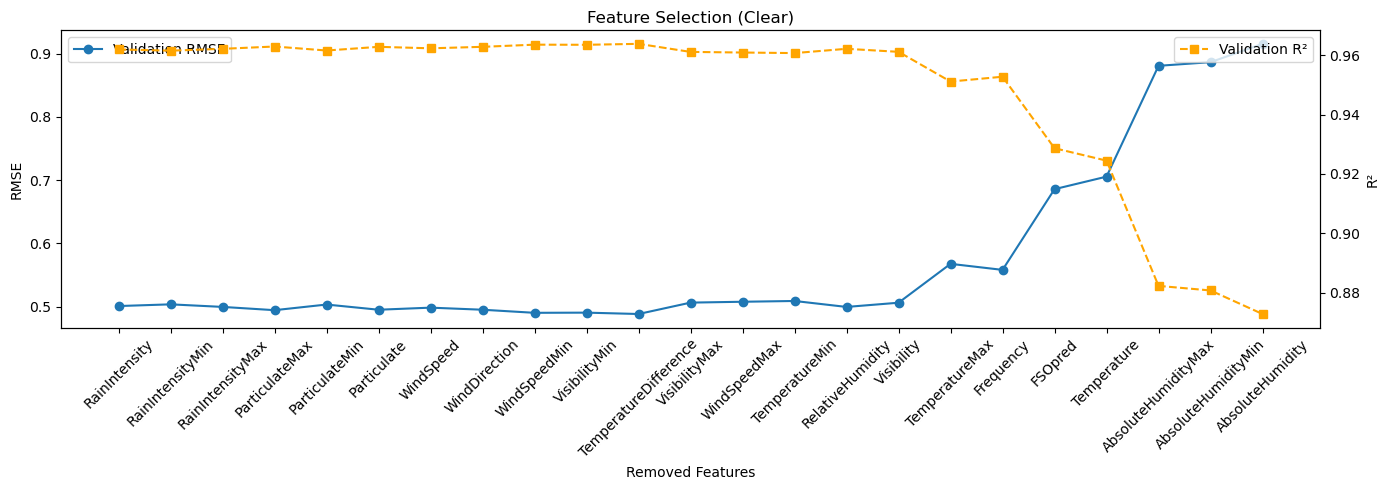

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'WindSpeedMax', 'FSOpred']
Optimal hyperparameters for RF model (Clear): {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}


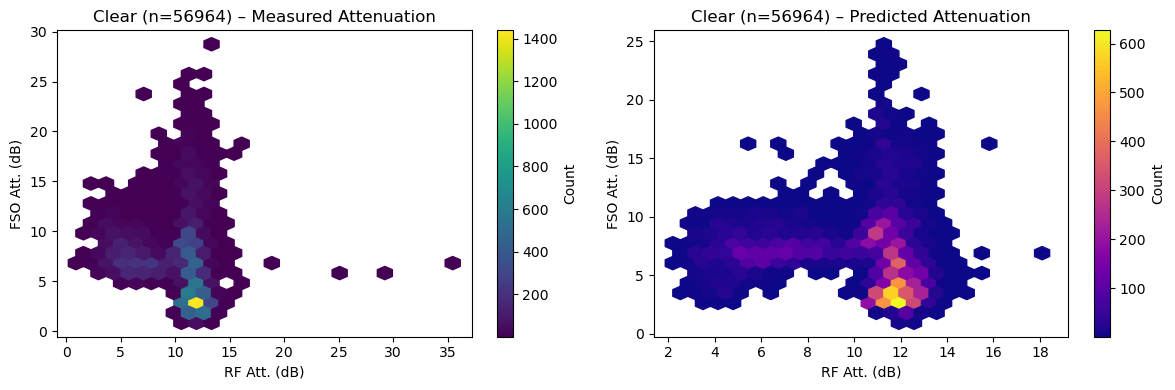


Processing: Dust (code 3)


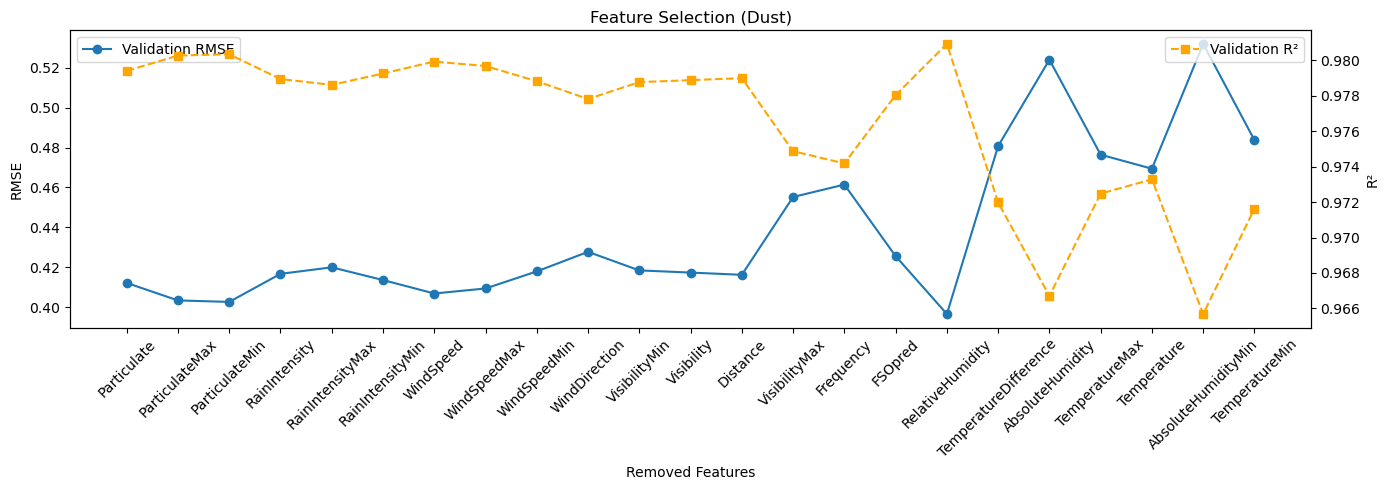

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeed', 'WindSpeedMax', 'WindSpeedMin', 'FSOpred']
Optimal hyperparameters for RF model (Dust): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


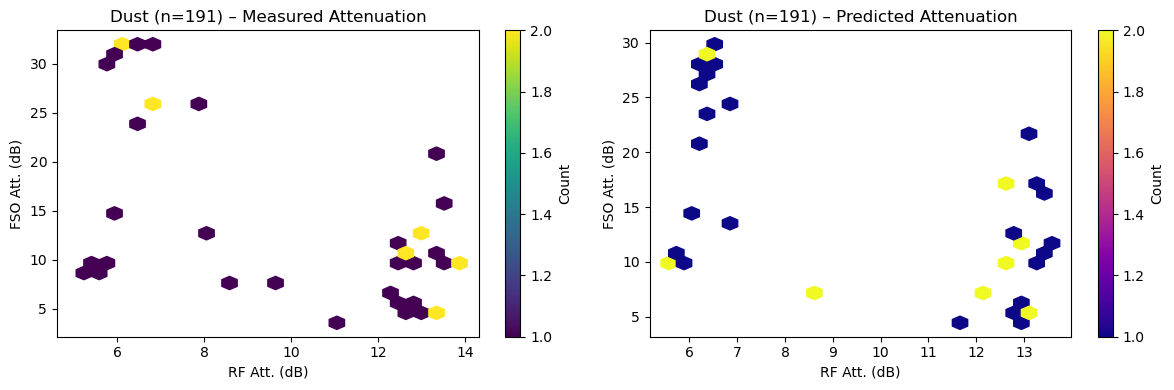


Processing: Fog (code 4)


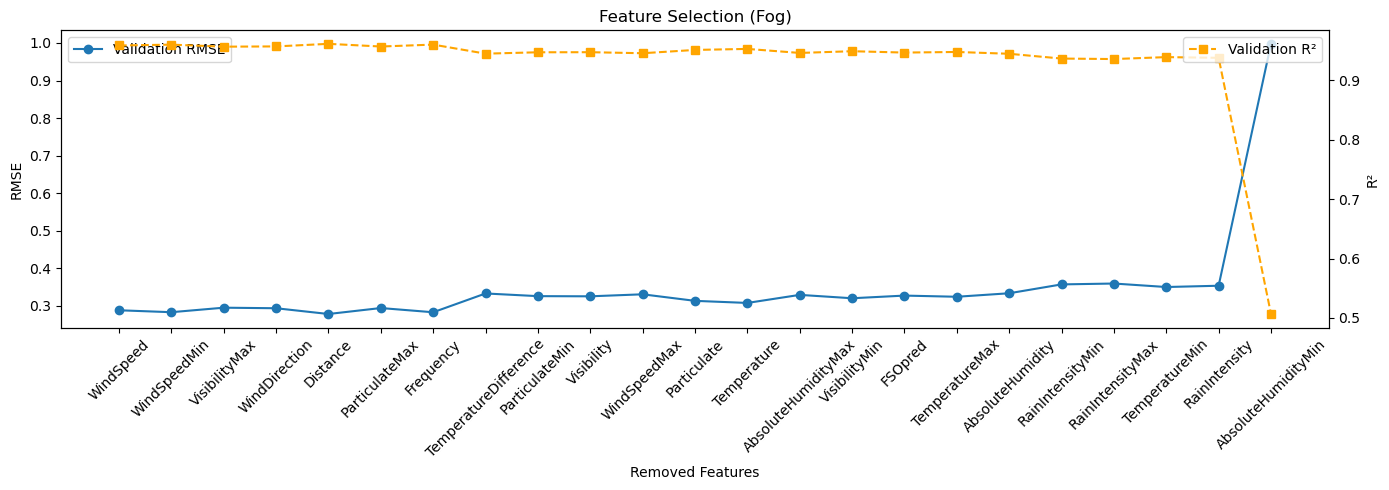

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeedMax', 'WindSpeedMin', 'FSOpred']
Optimal hyperparameters for RF model (Fog): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


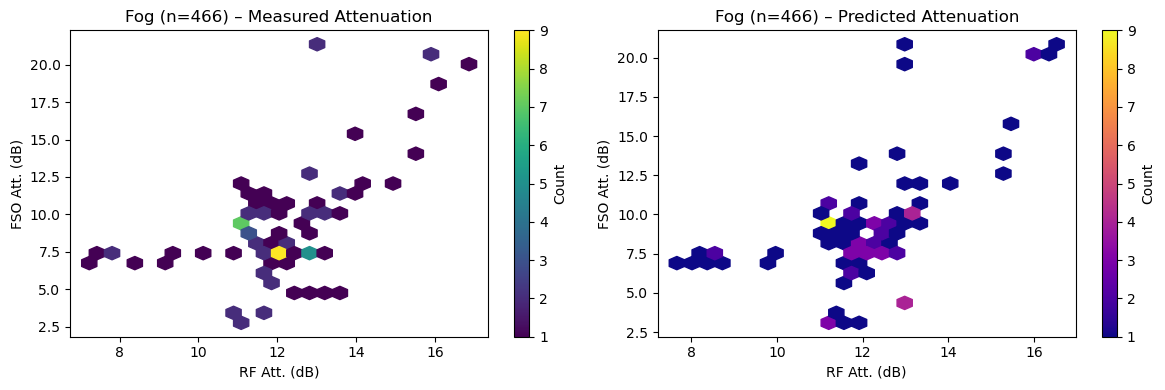


Processing: Drizzle (code 5)


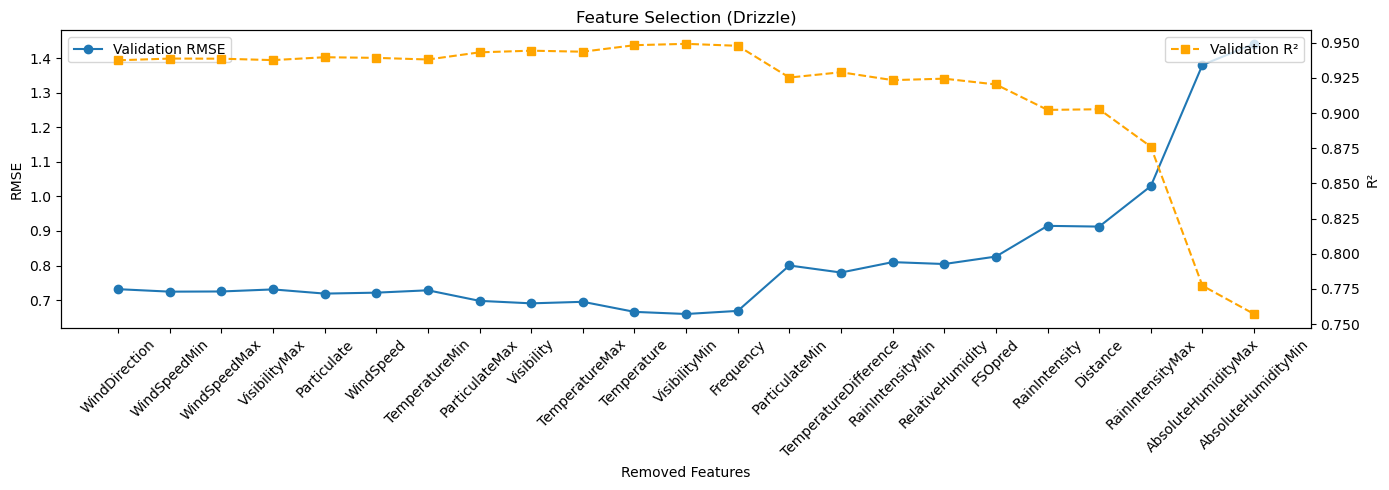

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'TemperatureDifference', 'FSOpred']
Optimal hyperparameters for RF model (Drizzle): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


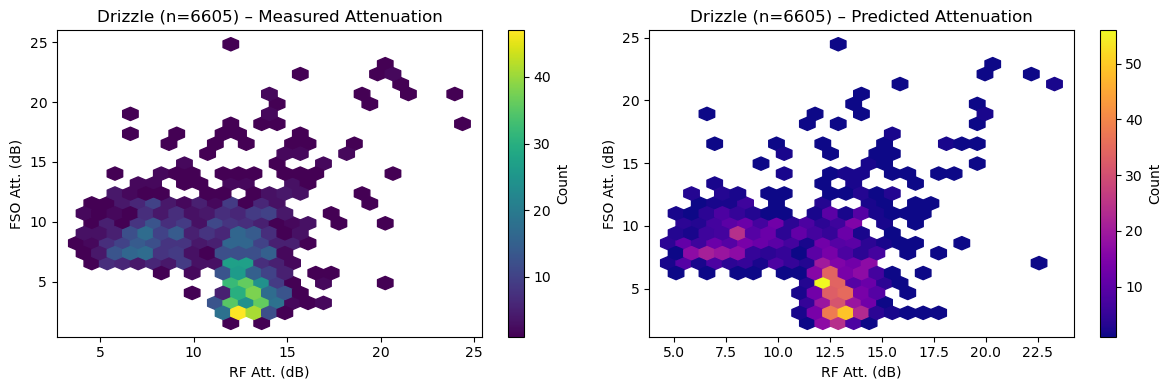


Processing: Rain (code 6)


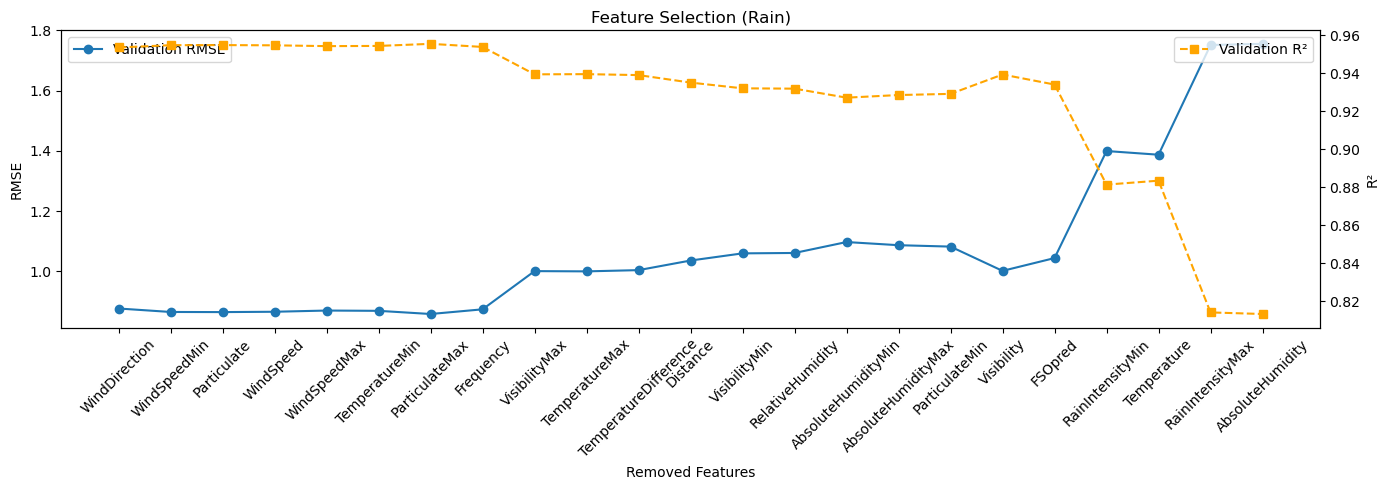

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'FSOpred']
Optimal hyperparameters for RF model (Rain): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


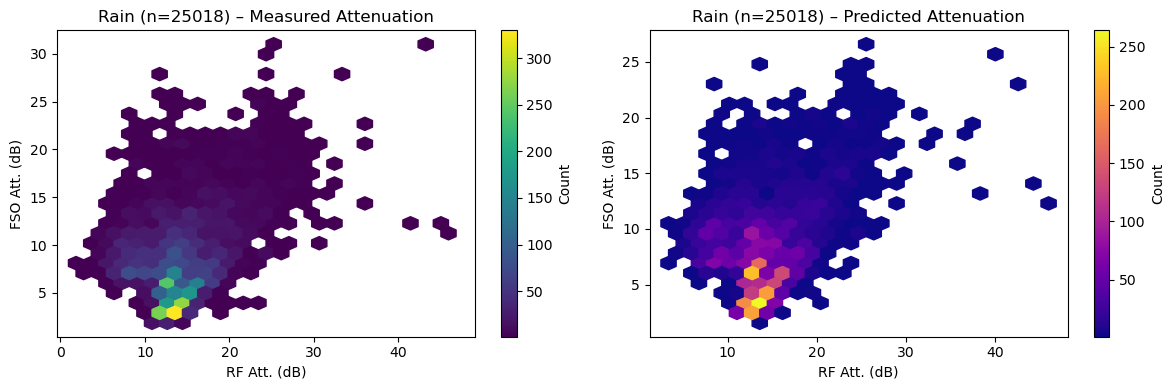


Processing: Snow (code 7)


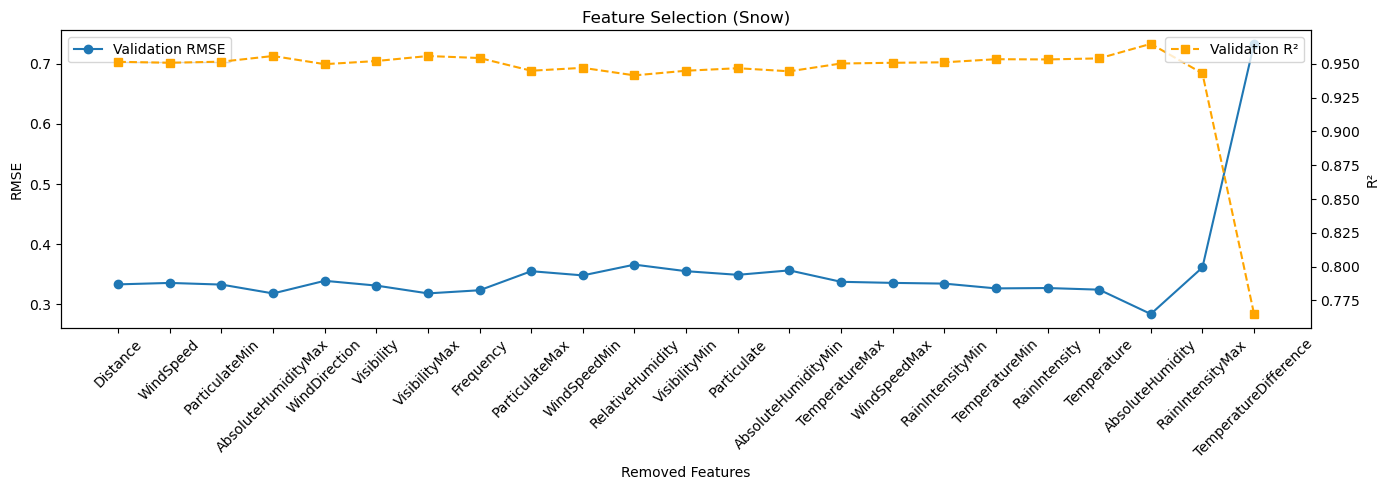

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Frequency', 'Particulate', 'ParticulateMax', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeedMax', 'WindSpeedMin', 'FSOpred']
Optimal hyperparameters for RF model (Snow): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


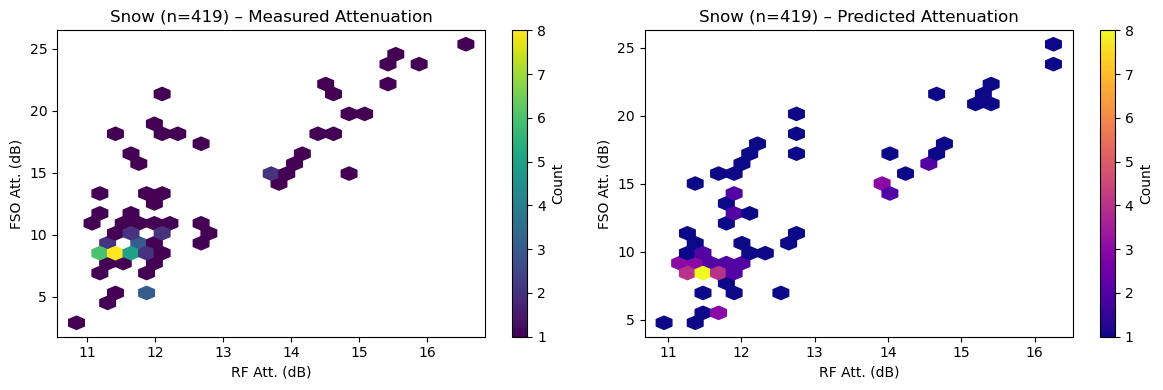


Processing: Showers (code 8)


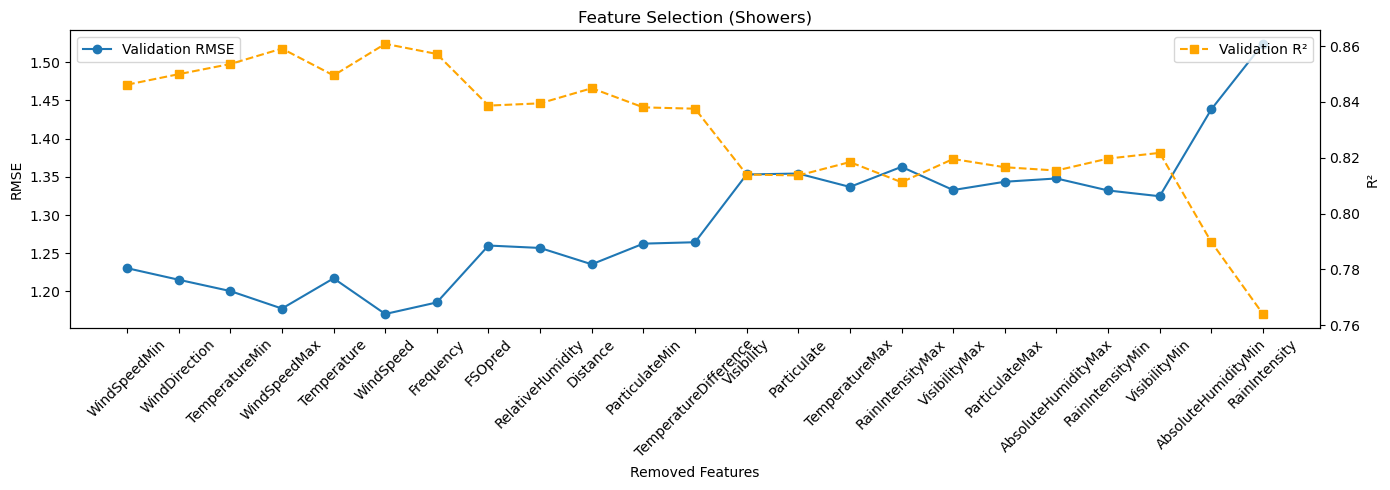

Chosen features for RF: ['AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindSpeed', 'WindSpeedMax', 'FSOpred']
Optimal hyperparameters for RF model (Showers): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


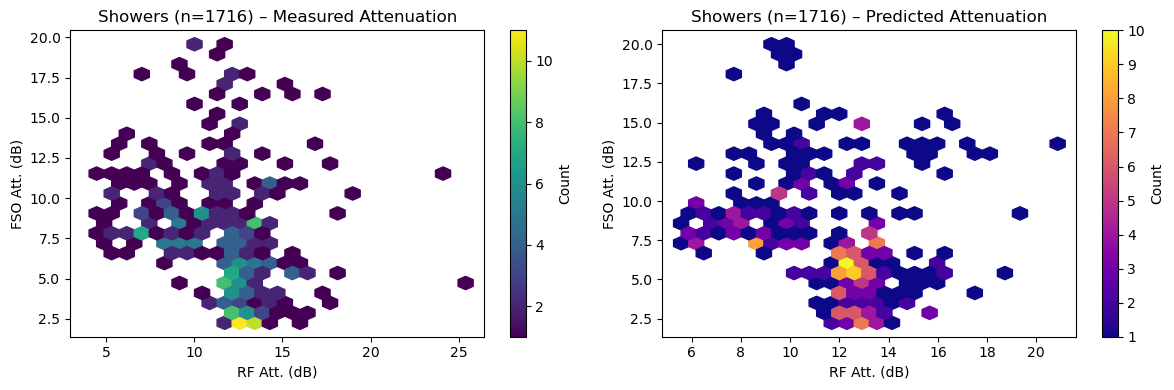


=== Summary Results ===
   Weather  FSO_RMSE    FSO_R2   RF_RMSE     RF_R2  Corr_Actual  \
0    Clear  1.657268  0.783640  0.440483  0.970447    -0.267705   
1     Dust  2.513228  0.927545  0.415876  0.983968    -0.424294   
2      Fog  0.924989  0.944628  0.522277  0.904161     0.577887   
3  Drizzle  1.215934  0.884447  0.658181  0.949679    -0.155631   
4     Rain  1.321541  0.904342  0.757435  0.963646     0.348307   
5     Snow  1.088311  0.955738  0.260756  0.963256     0.804480   
6  Showers  1.435518  0.860211  1.000804  0.883059    -0.169827   

   Corr_Predicted                                         FSO_Params  
0       -0.193170  {'n_estimators': 200, 'min_samples_split': 5, ...  
1       -0.546437  {'n_estimators': 100, 'min_samples_split': 2, ...  
2        0.593132  {'n_estimators': 50, 'min_samples_split': 2, '...  
3       -0.173390  {'n_estimators': 100, 'min_samples_split': 2, ...  
4        0.344072  {'n_estimators': 100, 'min_samples_split': 2, ...  
5        0.8

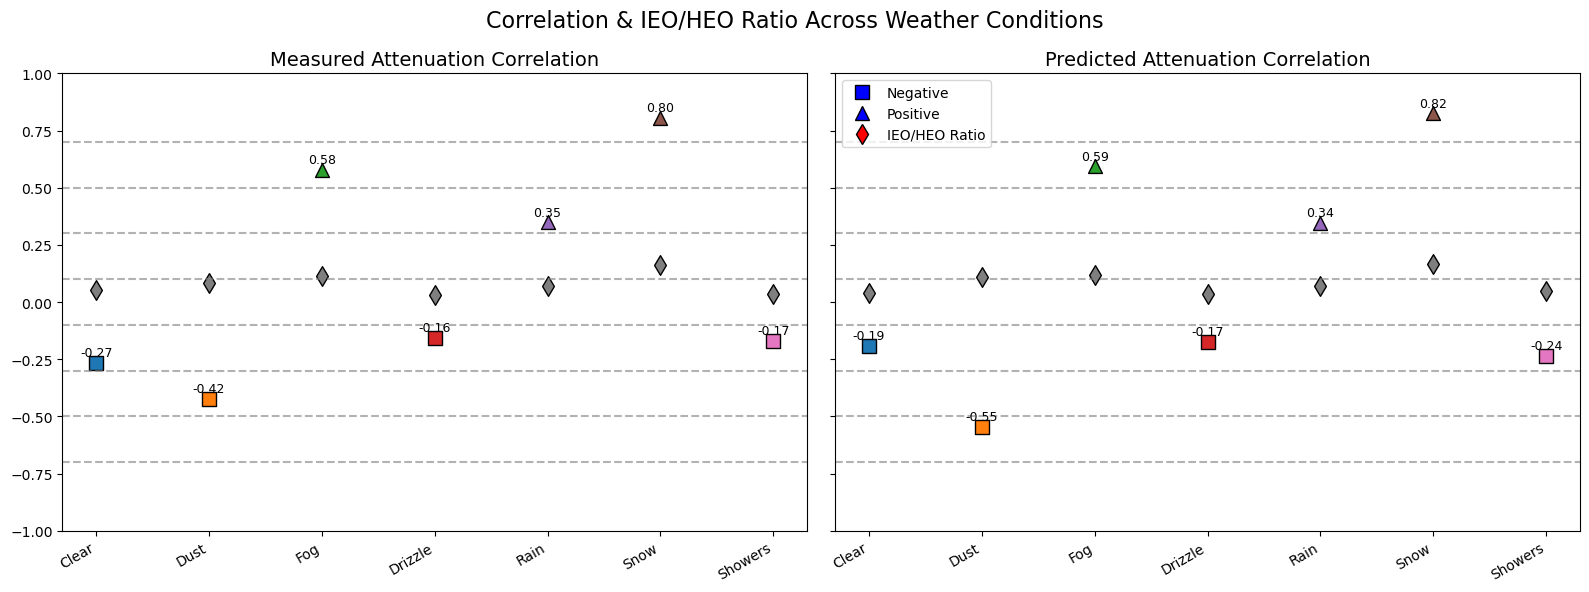

In [ ]:
# Using backward selection for feature selection

def backward_eliminate(df_features, target, estimator):
    active_feats = list(df_features.columns)
    history = []
    rmse_trace = []
    r2_trace = []
    removed_feats = []

    while len(active_feats) > 1:
        X_train, X_valid, y_train, y_valid = train_test_split(
            df_features[active_feats], target, test_size=0.2, random_state=42
        )
        estimator.fit(X_train, y_train)
        preds = estimator.predict(X_valid)
        rmse_val = sqrt(mean_squared_error(y_valid, preds))
        r2_val = r2_score(y_valid, preds)
        history.append((active_feats.copy(), rmse_val, r2_val))
        rmse_trace.append(rmse_val)
        r2_trace.append(r2_val)
        importances = estimator.feature_importances_
        lowest_feat = active_feats[np.argmin(importances)]
        active_feats.remove(lowest_feat)
        removed_feats.append(lowest_feat)

    return history, rmse_trace, r2_trace, removed_feats


# Function: plot RMSE and R² 

def draw_performance_curve(rmse_vals, r2_vals, dropped, title):
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(rmse_vals, 'o-', label='Validation RMSE')
    ax1.set_xlabel('Removed Features')
    ax1.set_ylabel('RMSE')
    ax1.set_xticks(range(len(dropped)))
    ax1.set_xticklabels(dropped, rotation=45)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(r2_vals, 's--', color='orange', label='Validation R²')
    ax2.set_ylabel('R²')
    ax2.legend(loc='upper right')
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Function: render density maps 

def render_density_map(true_rf, true_fso, pred_rf, pred_fso, subtitle):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Measured attenuation
    hb1 = axes[0].hexbin(true_rf, true_fso, gridsize=25, mincnt=1, cmap='viridis')
    axes[0].set_xlabel('RF Att. (dB)')
    axes[0].set_ylabel('FSO Att. (dB)')
    axes[0].set_title(f'{subtitle} – Measured Attenuation')
    plt.colorbar(hb1, ax=axes[0], label='Count')
    
    # Predicted attenuation
    hb2 = axes[1].hexbin(pred_rf, pred_fso, gridsize=25, mincnt=1, cmap='plasma')
    axes[1].set_xlabel('RF Att. (dB)')
    axes[1].set_ylabel('FSO Att. (dB)')
    axes[1].set_title(f'{subtitle} – Predicted Attenuation')
    plt.colorbar(hb2, ax=axes[1], label='Count')

    plt.tight_layout()
    plt.show()



if __name__ == '__main__':
    # Load data
    data = pd.read_csv('RFLFSODataFull.csv')

    # Weather codes mapping
    code_map = {
        'Clear': 0, 'Dust': 3, 'Fog': 4,
        'Drizzle': 5, 'Rain': 6, 'Snow': 7, 'Showers': 8
    }

    # Predefined FSO input sets per weather code
    fso_inputs = {
        0: ['AbsoluteHumidity', 'VisibilityMax', 'TemperatureMax','VisibilityMin','Temperature'],
        3: ['WindSpeedMax','TemperatureMax','TemperatureDifference','VisibilityMin','Temperature', 'Visibility','RelativeHumidity','Distance'],
        4: ['WindSpeedMax', 'TemperatureMin', 'Distance', 'Particulate', 'Temperature', 'RainIntensityMax'],
        5: ['Temperature','Visibility', 'ParticulateMax'],
        6: ['ParticulateMin', 'Visibility', 'Temperature', 'ParticulateMax', 'Distance'],
        7: ['Temperature', 'ParticulateMax', 'TemperatureDifference', 'ParticulateMin'],
        8: ['RelativeHumidity', 'VisibilityMax', 'VisibilityMin', 'Distance']
    }

    summary = []

    for weather, wcode in code_map.items():
        df_sub = data[data['SYNOPCode'] == wcode]
        if df_sub.shape[0] < 10:
            print(f"{weather}: too few rows ({df_sub.shape[0]}) - skipped")
            continue
        print(f"\nProcessing: {weather} (code {wcode})")

        X = df_sub.drop(['RFL_Att','FSO_Att'], axis=1)
        y_rf = df_sub['RFL_Att']
        y_fso = df_sub['FSO_Att']

        X_tr, X_te, y_rf_tr, y_rf_te, y_fso_tr, y_fso_te = train_test_split(
            X, y_rf, y_fso, test_size=0.2, random_state=42
        )

        # FSO baseline
        fso_feats = fso_inputs[wcode]
        fso_mod = RandomForestRegressor(n_estimators=100, random_state=42)
        fso_mod.fit(X_tr[fso_feats], y_fso_tr)
        fso_tr_pred = fso_mod.predict(X_tr[fso_feats])
        fso_te_pred = fso_mod.predict(X_te[fso_feats])

        # RF feature elimination
        rf_data_tr = X_tr.drop(['Time','SYNOPCode'], axis=1).copy()
        rf_data_tr['FSOpred'] = fso_tr_pred
        hist, rmses, r2s, drops = backward_eliminate(
            rf_data_tr, y_rf_tr,
            RandomForestRegressor(n_estimators=50, random_state=42)
        )
        draw_performance_curve(rmses, r2s, drops, f"Feature Selection ({weather})")

        # choose best features
        diffs = np.diff(rmses)
        idx = np.where(diffs > 0.01)[0]
        best_ix = idx[0] if idx.size else int(np.argmin(rmses))
        best_feats = hist[best_ix][0]
        print(f"Chosen features for RF: {best_feats}")

        # Hyperparameter search
        grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        search = RandomizedSearchCV(
            RandomForestRegressor(random_state=42),
            param_distributions=grid, n_iter=20, cv=5,
            scoring='neg_mean_squared_error', n_jobs=-1, random_state=42
        )
        search.fit(rf_data_tr[best_feats], y_rf_tr)

        # Print out the optimal hyperparameters
        print(f"Optimal hyperparameters for RF model ({weather}): {search.best_params_}")

        best_params = search.best_params_
        rf_mod = RandomForestRegressor(**best_params, random_state=42)
        rf_mod.fit(rf_data_tr[best_feats], y_rf_tr)

        # Evaluate
        rf_data_te = X_te.drop(['Time','SYNOPCode'], axis=1).copy()
        rf_data_te['FSOpred'] = fso_te_pred
        rf_te_pred = rf_mod.predict(rf_data_te[best_feats])

        m_rmse = sqrt(mean_squared_error(y_fso_te, fso_te_pred))
        m_r2   = r2_score(y_fso_te, fso_te_pred)
        f_rmse = sqrt(mean_squared_error(y_rf_te, rf_te_pred))
        f_r2   = r2_score(y_rf_te, rf_te_pred)
        corr_meas, _ = pearsonr(df_sub['FSO_Att'], df_sub['RFL_Att'])
        corr_pred, _ = pearsonr(fso_te_pred, rf_te_pred)

        summary.append({
            'Weather': weather,
            'FSO_RMSE': m_rmse, 'FSO_R2': m_r2,
            'RF_RMSE': f_rmse, 'RF_R2': f_r2,
            'Corr_Actual': corr_meas, 'Corr_Predicted': corr_pred,
            'FSO_Params': search.best_params_
        })

        # Plot per-weather density maps
        render_density_map(
            true_fso=y_fso_te.values,
            true_rf=y_rf_te.values,
            pred_fso=fso_te_pred,
            pred_rf=rf_te_pred,
            subtitle=f"{weather} (n={len(df_sub)})"
        )

    # Summary table
    summary_df = pd.DataFrame(summary)
    print("\n=== Summary Results ===")
    print(summary_df)


    # Final correlation comparison plot
    measured_ieo_heo  = np.abs(summary_df['Corr_Actual'].values) * 0.2
    predicted_ieo_heo = np.abs(summary_df['Corr_Predicted'].values) * 0.2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Left plot: measured correlations
    for i, corr in enumerate(summary_df['Corr_Actual']):
        mark = '^' if corr >= 0 else 's'
        ax1.scatter(i, corr, marker=mark, s=100, edgecolors='black')
        ax1.text(i, corr + 0.03, f"{corr:.2f}", ha='center', fontsize=9)
    ax1.scatter(range(len(summary_df)), measured_ieo_heo, marker='d', s=100, edgecolors='black')
    ax1.set_title("Measured Attenuation Correlation", fontsize=14)
    ax1.set_xticks(range(len(summary_df)))
    ax1.set_xticklabels(summary_df['Weather'], rotation=30, ha='right')
    ax1.set_ylim(-1, 1)
    for y in [0.7, 0.5, 0.3, 0.1, -0.1, -0.3, -0.5, -0.7]:
        ax1.axhline(y, color='gray', linestyle='--', alpha=0.6)

    # Right plot: predicted correlations
    for i, corr in enumerate(summary_df['Corr_Predicted']):
        mark = '^' if corr >= 0 else 's'
        ax2.scatter(i, corr, marker=mark, s=100, edgecolors='black')
        ax2.text(i, corr + 0.03, f"{corr:.2f}", ha='center', fontsize=9)
    ax2.scatter(range(len(summary_df)), predicted_ieo_heo, marker='d', s=100, edgecolors='black')
    ax2.set_title("Predicted Attenuation Correlation", fontsize=14)
    ax2.set_xticks(range(len(summary_df)))
    ax2.set_xticklabels(summary_df['Weather'], rotation=30, ha='right')
    ax2.set_ylim(-1, 1)
    for y in [0.7, 0.5, 0.3, 0.1, -0.1, -0.3, -0.5, -0.7]:
        ax2.axhline(y, color='gray', linestyle='--', alpha=0.6)

    handles = [
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', label='Negative', markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='Positive', markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='d', color='w', markerfacecolor='red', label='IEO/HEO Ratio', markersize=10, markeredgecolor='black')
    ]
    ax2.legend(handles=handles, loc='upper left', fontsize=10)

    plt.suptitle("Correlation & IEO/HEO Ratio Across Weather Conditions", fontsize=16)
    plt.tight_layout()
    plt.show()